# **Importing Libraries**

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import tensorflow as tf


# **Loading Dataset**

In [20]:
IMG_SIZE = 224
classes = ["notumor", "pituitary"]

train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"


def load_images(path):
    images = []
    labels = []

    for label, cls in enumerate(classes):
        folder = os.path.join(path, cls)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


X_train, y_train = load_images(train_path)
X_test, y_test = load_images(test_path)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (2800, 224, 224, 3)
Test: (800, 224, 224, 3)


In [21]:
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Preprocessing 
**Resize + Normalize + Noise Removal**

In [22]:
def preprocess(images):
    processed = []

    for img in images:
        img = cv2.GaussianBlur(img,(3,3),0)   
        img = preprocess_input(img)           
        processed.append(img)

    return np.array(processed)

X_train = preprocess(X_train)
X_test = preprocess(X_test)


# Image Augmentation

We apply 3 techniques:
1. Rotation
2. Flipping
3. Contrast/Brightness change

In [23]:
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)


# How Augmentation Helps Detection 

1. Rotation → detects tumors at different orientations

2. Flipping → improves spatial robustness

3. Contrast change → enhances subtle boundaries

4. Prevents overfitting

5. Helps model detect small structural variations

# Feature Extraction

We extract:

1. Canny edges
2. Texture using intensity histogram (GLCM alternative simplified)

In [24]:
def extract_features(images):
    features = []

    for img in images:
        img = ((img + 1) * 127.5).astype(np.uint8)  
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Edge detection
        edges = cv2.Canny(gray,100,200)
        edges = cv2.resize(edges,(32,32)).flatten()

        # Texture histogram
        hist = cv2.calcHist([gray],[0],None,[64],[0,256]).flatten()

        features.append(np.hstack([edges,hist]))

    return np.array(features)

X_train_feat = extract_features(X_train)
X_test_feat = extract_features(X_test)


# Training Classical ML Model


In [25]:
svm = SVC(kernel="rbf")
svm.fit(X_train_feat, y_train)

y_pred = svm.predict(X_test_feat)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Accuracy: 0.9472222222222222
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       360
           1       0.95      0.95      0.95       360

    accuracy                           0.95       720
   macro avg       0.95      0.95      0.95       720
weighted avg       0.95      0.95      0.95       720



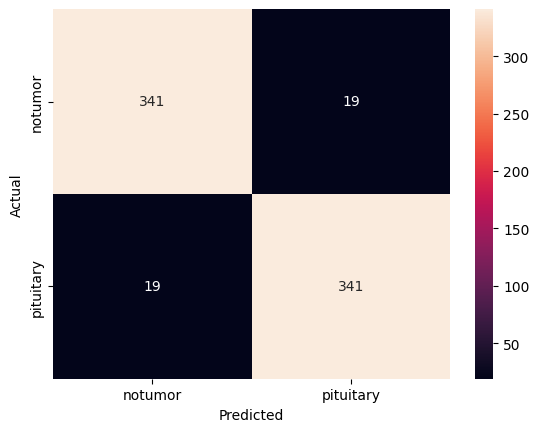

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# CNN Model

In [27]:
y_train_cat = to_categorical(y_train,2)
y_test_cat = to_categorical(y_test,2)

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(2,activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    datagen.flow(X_train,y_train_cat,batch_size=32),
    epochs=5,
    validation_data=(X_test,y_test_cat)
)

cnn_acc = cnn.evaluate(X_test,y_test_cat)[1]
print("CNN Accuracy:",cnn_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 304ms/step - accuracy: 0.7635 - loss: 1.8818 - val_accuracy: 0.9375 - val_loss: 0.1996
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 285ms/step - accuracy: 0.9421 - loss: 0.1657 - val_accuracy: 0.9778 - val_loss: 0.0642
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.9704 - loss: 0.0851 - val_accuracy: 0.9889 - val_loss: 0.0491
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 286ms/step - accuracy: 0.9751 - loss: 0.0661 - val_accuracy: 0.9861 - val_loss: 0.0446
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 283ms/step - accuracy: 0.9862 - loss: 0.0444 - val_accuracy: 0.9917 - val_loss: 0.0402
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9924 - loss: 0.0329
CNN Accuracy: 0.9916666746139526


# Transfer Learning (MobileNetV2)

In [28]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2,activation='softmax')(x)

model = Model(inputs=base_model.input,outputs=output)

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    datagen.flow(X_train,y_train_cat,batch_size=32),
    epochs=5,
    validation_data=(X_test,y_test_cat)
)

transfer_acc = model.evaluate(X_test,y_test_cat)[1]
print("MobileNet Accuracy:",transfer_acc)


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 375ms/step - accuracy: 0.9208 - loss: 0.2940 - val_accuracy: 0.9694 - val_loss: 0.0838
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 290ms/step - accuracy: 0.9896 - loss: 0.0340 - val_accuracy: 0.9903 - val_loss: 0.0273
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 285ms/step - accuracy: 0.9964 - loss: 0.0155 - val_accuracy: 0.9903 - val_loss: 0.0573
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.9964 - loss: 0.0155 - val_accuracy: 0.9958 - val_loss: 0.0099
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 290ms/step - accuracy: 0.9968 - loss: 0.0077 - val_accuracy: 0.9931 - val_loss: 0.0120
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9952 - loss: 0.0069
MobileNet Accuracy: 0.9930555820465088


# Comparing ML vs CNN

In [33]:
print(f"SVM: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"CNN: {cnn_acc * 100:.2f}%")
print(f"MobileNet: {transfer_acc * 100:.2f}%")

SVM: 94.72%
CNN: 99.17%
MobileNet: 99.31%


# Grad-CAM Visualization

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_332']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


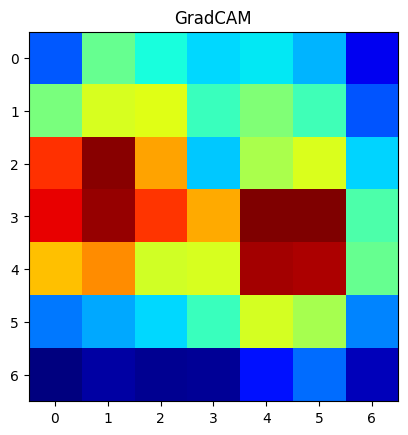

In [34]:
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = model.get_layer("Conv_1")

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        class_channel = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)/tf.math.reduce_max(heatmap)
    return heatmap.numpy()


img = X_test[0]
heatmap = make_gradcam_heatmap(np.expand_dims(img,0),model)

plt.imshow(heatmap,cmap="jet")
plt.title("GradCAM")
plt.show()


# Saving Model (For Web Deployment)

In [35]:
model.save("brain_tumor_model.h5")